# Vergelijking met Winkels & De Ruyter (Hoge Raad)




## data laden en preprocessen




In [26]:
import pandas as pd
import networkx as nx
import re
from collections import Counter
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [27]:
%%time
df= pd.read_csv('LidoLinks.csv.gz', header=None)
print(df.shape)
df.head()


(7355861, 2)
CPU times: total: 9.33 s
Wall time: 9.57 s


,0,1
0,jurisprudentie/id/ECLI:NL:RBAMS:2015:6776,bwb/id/BWBR0001854/2967974/1984-05-01/1984-05-01
1,jurisprudentie/id/ECLI:NL:RBOBR:2018:4470,bwb/id/BWBR0005290/2913524/2018-07-28/2018-07-28
2,jurisprudentie/id/ECLI:NL:RBAMS:2019:4496,bwb/id/BWBR0001854/2963144/1986-05-19/1986-05-19
3,jurisprudentie/id/ECLI:NL:RBOVE:2024:2366,bwb/id/BWBR0001827/3178144/2002-01-01/2002-01-01
4,jurisprudentie/id/ECLI:NL:RBUTR:2006:BA7009,bwb/id/BWBR0002375/2060994/2006-01-01/2006-01-01


In [28]:
%%time
# haal de datums van de id's af. Dit werkt alleen op de bwb/id knopen
df[1]=df[1].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 
df[0]=df[0].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 

CPU times: total: 24.2 s
Wall time: 24.5 s


In [29]:
df['groep_s'] = df[0].str.replace(r'/id.*', r'', regex=True)
df['groep_t'] = df[1].str.replace(r'/id.*', r'', regex=True)

## 1. Winkels: Hoge raad

Winkels & De Ruyter (2012) rapporteren een netwerk van 15.053 uitspraken van de Hoge Raad met 106.559 verwijzingen. In het LIDO-bestand filteren op jurisprudentie type met ECLI-patronen voor de Hoge Raad.


### 1.1 Wat staat er in Winkels & De Ruyter (2012)?

Uit de paper (Winkels & de Ruyter 2012, Survival of the Fittest):

* 15.053 HR-uitspraken gepubliceerd in NJ, 1 jan 1965 – 31 dec 2008, 106.559 door hun parser gevonden referenties (F1 ≈ 99%);

* gem. in-degree ≈ 1 tot en met de jaren '80, loopt op tot ≈ 2 in de jaren 2000 

* top-10 thema's: 8 van de top-10 gaan over procesrecht, 2 over familierecht, de bekendste is Zwolsman.

Scope van hun network (belangrijk, want dat is smaller dan ons LIDO):
* alleen Hoge Raad
* alleen uitspraken gepubliceerd in NJ (Nederlandse Jurisprudentie, Kluwer);
* alleen citaties naar andere NJ-HR-uitspraken — referenties naar HR-uitspraken buiten NJ vallen weg;


### 1.2 Wat hebben wij in LIDO

We hebben geen toegang tot de originele Kluwer-dataset die in Winkels (2012) is gebruikt. Ons LIDO-netwerk is ruimer:

* alle gepubliceerde HR-uitspraken, ongeacht of ze in NJ staan (ECLI);
* niet alleen HR → HR maar alle verwijzingen, zoals HR → bwb, HR → EU, enz.;
* geldt tot ver na 2008;

### 1.3 Hoe vergelijken

4 datasets:

`G_all_HR` alle HR-uitspraken in LIDO, alle uitgaande edges, alle jaren 

`G_HR_HR` alle HR-uitspraken in LIDO, alleen HR → HR , alle jaren

`G_repro` HR-uitspraken met bronjaar ∈ [1965, 2008], HR → HR binnen die periode (beste kopie van Winkels' dataset)

`G_ext`   HR-uitspraken t/m heden, HR → HR van 1965–heden


G_repro verschillen met Winkels' dataset:

1. zij hebben alleen NJ HR-uitspraken, wij hebben alle ECLI:NL:HR-uitspraken. Dit zorgt voor een hoger aantal nodes bij ons.
2. zij herkennen NJ-referentiepatronen, wij herkennen ECLI. Wij missen cases die alleen met een NJ-nummer naar elkaar verwijzen en waar geen ECLI-mapping voor is.
3. oude HR-uitspraken die nu pas een ECLI hebben gekregen, kunnen na 2008 nog nieuwe inkomende edges hebben gekregen.




In [63]:
# alle HR uitspraken slecteren

hr_filtered_s = df[0].str.contains(r'ECLI.NL.HR', regex=True, na=False)
hr_filtered_t = df[1].str.contains(r'ECLI.NL.HR', regex=True, na=False)



df_hr = df[hr_filtered_s & hr_filtered_t].copy()
print(f'HR->HR edges: {len(df_hr):,}')
print(f'Unieke HR nodes (source): {df_hr[0].nunique():,}')
print(f'Unieke HR nodes (target): {df_hr[1].nunique():,}')

# Alle HR nodes
all_hr_nodes = set(df_hr[0]) | set(df_hr[1])
print(f'Totaal unieke HR nodes: {len(all_hr_nodes):,}')

HR->HR edges: 26,257
Unieke HR nodes (source): 14,039
Unieke HR nodes (target): 12,341
Totaal unieke HR nodes: 21,908


In [64]:
# het hele Hoge Raad subnetwerk bouwen
G_hr = nx.from_pandas_edgelist(df_hr, source=0, target=1, create_using=nx.DiGraph())
print(f'HR netwerk: {G_hr.number_of_nodes():,} nodes, {G_hr.number_of_edges():,} edges')
print(f'Dichtheid: {nx.density(G_hr):.6f}')

HR netwerk: 21,908 nodes, 26,257 edges
Dichtheid: 0.000055


In [65]:
YEAR_REGEX = re.compile(r'ECLI[.:]NL[.:][A-Z]+[.:](\d{4})[.:]')

def ecli_year(u):
    m = YEAR_REGEX.search(str(u))
    return int(m.group(1)) if m else None

bron_hr = df[0].astype(str).str.contains(r'ECLI[.:]NL[.:]HR[.:]', na=False) 
target_hr = df[1].astype(str).str.contains(r'ECLI[.:]NL[.:]HR[.:]', na=False)

print(f'edges met HR als bron: {bron_hr.sum()}')
print(f'edges met HR als target: {target_hr.sum()}')
print(f'edges HR->HR: {(bron_hr & target_hr).sum()}')
print(f'edges HR->iets anders: {(bron_hr & ~target_hr).sum()}')
print(f'edges iets anders->HR: {(~bron_hr & target_hr).sum()}')

edges met HR als bron: 263940
edges met HR als target: 466924
edges HR->HR: 26257
edges HR->iets anders: 237683
edges iets anders->HR: 440667


In [ ]:
#   G_all_HR:  elke edge die HR aan beide uiteinden heeft (HR--HR)
#   G_HR_HR:   alleen HR->HR
#   G_repro:   G_HR_HR beperkt tot 1965-2008 
#   G_ext:     G_HR_HR alle jaren t/m heden

WINKELS_START, WINKELS_END = 1965, 2008

df_hrhr = df[bron_hr & target_hr].copy()
df_hrhr['src_year'] = df_hrhr[0].map(ecli_year)
df_hrhr['tgt_year'] = df_hrhr[1].map(ecli_year)


# alle edges waar bron HR is
df_all_hr = df[bron_hr].copy()

G_all_HR = nx.from_pandas_edgelist(
    df_all_hr, source=0, target=1, create_using=nx.DiGraph()
)

# alle jaren, incl. pre-1965
G_HR_HR = nx.from_pandas_edgelist(df_hrhr, source=0, target=1, create_using=nx.DiGraph()) 

# alleen 1965–2008
df_repro = df_hrhr[
    df_hrhr['src_year'].between(WINKELS_START, WINKELS_END) &
    df_hrhr['tgt_year'].between(WINKELS_START, WINKELS_END)
]
G_repro = nx.from_pandas_edgelist(df_repro, source=0, target=1, create_using=nx.DiGraph())

# 1965–heden
df_ext = df_hrhr[
    (df_hrhr['src_year'] >= WINKELS_START) &
    (df_hrhr['tgt_year'] >= WINKELS_START)
]
G_ext = nx.from_pandas_edgelist(df_ext, source=0, target=1, create_using=nx.DiGraph())


# Waarden vergelijking

In [ ]:


in_deg  = dict(G_hr.in_degree())
out_deg = dict(G_hr.out_degree())

in_val  = list(in_deg.values())
out_val = list(out_deg.values())



eigen_waarden= {
    'nodes': G_hr.number_of_nodes(),
    'edges': G_hr.number_of_edges(),
    'density': round(nx.density(G_hr), 6),
    'gem. indegree': round(np.mean(in_val), 2),
    'max indegree': max(in_val),
    'gem. outdegree': round(np.mean(out_val), 2),
    'max outdegree': max(out_val),
}

print(eigen_waarden)





# waarden van Winkels uit paper
# 15.053 uitspraken, 106.559 refs (inclusief citaties NAAR HR vanuit andere courts)
#   HR->HR subset kleiner; exacte cijfers niet volledig in paper.


waarden_winkels = {
'nodes': 15053,
'edges': 106559, #'(HR→HR: 7.992)'
'density':        None,         # niet expliciet in paper
'gem. indegree':  None,
'max indegree':   None,
'gem. outdegree': None,
'max outdegree':  None, 
}

{'nodes': 21908, 'edges': 26257, 'density': 5.5e-05, 'gem. indegree': np.float64(1.2), 'max indegree': 183, 'gem. outdegree': np.float64(1.2), 'max outdegree': 52}


,ons HR-subnet,Winkels 2011/12
nodes,21908.000000,15053.0
edges,26257.000000,106559.0
density,0.000055,NaN
gem. indegree,1.200000,NaN
max indegree,183.000000,NaN
gem. outdegree,1.200000,NaN
max outdegree,52.000000,NaN


G_repro (1965-2008):


,n,mean_indeg,median_indeg
decade,,,
1960,79,1.127,1.0
1970,284,1.158,1.0
1980,864,1.294,1.0
1990,2471,1.254,1.0
2000,3959,0.630,0.0



G_HR_HR (alle jaren):


,n,mean_indeg,median_indeg
decade,,,
1900,1,1.000,1.0
1910,17,1.059,1.0
1920,32,1.125,1.0
1930,45,1.133,1.0
1940,41,1.171,1.0
1950,215,1.237,1.0
1960,221,1.312,1.0
1970,384,1.328,1.0
1980,1110,1.612,1.0


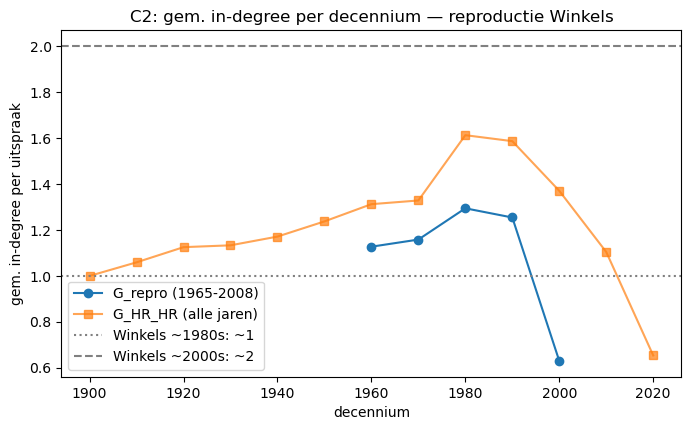

In [68]:
#in-degree per decennium

def indeg_per_decade(H):
    df2 = pd.DataFrame(H.in_degree(), columns=['node', 'indeg'])

    df2['year'] = df2['node'].map(ecli_year)
    df2 = df2.dropna(subset=['year'])
    df2['decade'] = (df2['year'] // 10) * 10

    return df2.groupby('decade')['indeg'].agg(
        n='size',
        mean_indeg='mean',
        median_indeg='median'
    ).round(3)


agg_repro = indeg_per_decade(G_repro)
agg_alle   = indeg_per_decade(G_HR_HR)

print('G_repro (1965-2008):')
display(agg_repro)
print()
print('G_HR_HR (alle jaren):')
display(agg_alle)

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(agg_repro.index, agg_repro['mean_indeg'], marker='o', label='G_repro (1965-2008)')
ax.plot(agg_alle.index,   agg_alle['mean_indeg'],   marker='s', label='G_HR_HR (alle jaren)', alpha=0.7)
ax.axhline(1.0, color='gray', ls=':', label='Winkels ~1980s: ~1')
ax.axhline(2.0, color='gray', ls='--', label='Winkels ~2000s: ~2')
ax.set_xlabel('decennium'); ax.set_ylabel('gem. in-degree per uitspraak')
ax.set_title('C2: gem. in-degree per decennium — reproductie Winkels')
ax.legend(); plt.show()

In [69]:
# 1.8b  Expliciete beslisregel voor C2
repro_1980s = agg_repro.loc[1980, 'mean_indeg'] if 1980 in agg_repro.index else float('nan')
repro_2000s = agg_repro.loc[2000, 'mean_indeg'] if 2000 in agg_repro.index else float('nan')

print(f'onze G_repro:  decennium 1980 mean in-degree = {repro_1980s:.2f}  (Winkels: ~1)')
print(f'               decennium 2000 mean in-degree = {repro_2000s:.2f}  (Winkels: ~2)')
print()



onze G_repro:  decennium 1980 mean in-degree = 1.29  (Winkels: ~1)
               decennium 2000 mean in-degree = 0.63  (Winkels: ~2)



Afwijking mogelijk door NJ-filter, 

# TOp 10 

8 van de top-10 meest geciteerde zaken in Winkels’ analyse gaan over procesrecht, 2 over familierecht, de bekendste is het Zwolsman-arrest 

In [73]:
in_deg_repro = dict(G_repro.in_degree())
top10_repro = sorted(in_deg_repro.items(), key=lambda x:-x[1])[:10]



tbl = pd.DataFrame({
    'ECLI (top-10 in-deg)': [n for n,_ in top10_repro],
    'in-deg':               [d for _,d in top10_repro],
    'bronjaar':             [ecli_year(n) for n,_ in top10_repro],
    
})
print('Top-10 HR-arresten in G_repro (1965-2008)')
display(tbl)

Top-10 HR-arresten in G_repro (1965-2008)


,ECLI (top-10 in-deg),in-deg,bronjaar
0,jurisprudentie/id/ECLI:NL:HR:2000:AA7309,62,2000
1,jurisprudentie/id/ECLI:NL:HR:2008:BC8789,39,2008
2,jurisprudentie/id/ECLI:NL:HR:2002:AD5163,32,2002
3,jurisprudentie/id/ECLI:NL:HR:1981:AG4158,30,1981
4,jurisprudentie/id/ECLI:NL:HR:2006:AU9130,30,2006
5,jurisprudentie/id/ECLI:NL:HR:2004:AM2533,28,2004
6,jurisprudentie/id/ECLI:NL:HR:2003:AF9473,18,2003
7,jurisprudentie/id/ECLI:NL:HR:2008:BD2578,17,2008
8,jurisprudentie/id/ECLI:NL:HR:2004:AO1427,14,2004
9,jurisprudentie/id/ECLI:NL:HR:1994:AB7528,13,1994


In [78]:
# fetch metadata + inhoudsindicatie via Open Data API

import time
import re
import requests
import xml.etree.ElementTree as ET

BASE_URL = 'https://data.rechtspraak.nl/uitspraken/content'

def _ecli_to_api_id(uri):
    m = re.search(r'ECLI[.:]NL[.:]([A-Z]+)[.:]([0-9]{4})[.:]([A-Z0-9.]+)', uri, re.I)
    if m:
        nr = m.group(3).replace('.', ':').upper()
        return f'ECLI:NL:{m.group(1).upper()}:{m.group(2)}:{nr}'
    return uri

def fetch_ecli_meta(ecli_id, sleep=1.1):
    """
    Haalt metadata op voor één ECLI.
    Retourneert dict met rechtsgebied (list), titel, datum, inhoud, status.
    """
    time.sleep(sleep)
    result = {'ecli': ecli_id, 'rechtsgebied': [], 'titel': '', 'datum': '', 'inhoud': '', 'status': 0}
    try:
        r = requests.get(BASE_URL, params={'id': ecli_id, 'return': 'META'}, timeout=15)
        result['status'] = r.status_code
        if r.status_code != 200:
            return result
        root = ET.fromstring(r.content)

        
        for subj in root.iter('{http://purl.org/dc/terms/}subject'):
            text = (subj.text or '').strip()
            if text:
                parts = [p.strip() for p in text.split(';') if p.strip()]
                result['rechtsgebied'].extend(parts)

        
        for t in root.iter('{http://purl.org/dc/terms/}title'):
            result['titel'] = (t.text or '').strip()
            break

        
        for d in root.iter('{http://purl.org/dc/terms/}date'):
            result['datum'] = (d.text or '').strip()
            break

        #
        parts = []
        for abstr in root.iter('{http://purl.org/dc/terms/}abstract'):
            t = (abstr.text or '').strip()
            if t:
                parts.append(t)
        
        for inh in root.iter('{http://www.rechtspraak.nl/schema/rechtspraak-1.0}inhoudsindicatie'):
            t = ' '.join(inh.itertext()).strip()
            if t:
                parts.append(t)
        result['inhoud'] = ' '.join(parts)[:4000]
    except Exception as e:
        result['fout'] = str(e)
    return result



ecli_meta_cache = {}   
texts_cache     = {}  

rows = []
for uri, indeg in top10_repro:
    ecli_id = _ecli_to_api_id(uri)
    meta    = fetch_ecli_meta(ecli_id)
    ecli_meta_cache[uri] = meta
    if meta['inhoud']:
        texts_cache[uri] = meta['inhoud']
    rg = '; '.join(meta['rechtsgebied']) if meta['rechtsgebied'] else '(niet gevonden)'
    rows.append({
        'ECLI':         ecli_id,
        'in-deg':       indeg,
        'jaar':         ecli_year(uri),
        'rechtsgebied': rg,
        'HTTP-status':  meta['status'],
    })
    print(f"  {ecli_id:<45}  {rg[:60]}")

c4_df = pd.DataFrame(rows)
print()
print('C4 — Top-10 arresten met rechtsgebied (Open Data API):')
display(c4_df)






  ECLI:NL:HR:2000:AA7309                         Strafrecht
  ECLI:NL:HR:2008:BC8789                         Strafrecht
  ECLI:NL:HR:2002:AD5163                         Strafrecht
  ECLI:NL:HR:1981:AG4158                         Civiel recht
  ECLI:NL:HR:2006:AU9130                         Strafrecht
  ECLI:NL:HR:2004:AM2533                         Strafrecht
  ECLI:NL:HR:2003:AF9473                         Strafrecht
  ECLI:NL:HR:2008:BD2578                         Strafrecht
  ECLI:NL:HR:2004:AO1427                         Civiel recht
  ECLI:NL:HR:1994:AB7528                         Strafrecht

C4 — Top-10 arresten met rechtsgebied (Open Data API):


,ECLI,in-deg,jaar,rechtsgebied,HTTP-status
0,ECLI:NL:HR:2000:AA7309,62,2000,Strafrecht,200
1,ECLI:NL:HR:2008:BC8789,39,2008,Strafrecht,200
2,ECLI:NL:HR:2002:AD5163,32,2002,Strafrecht,200
3,ECLI:NL:HR:1981:AG4158,30,1981,Civiel recht,200
4,ECLI:NL:HR:2006:AU9130,30,2006,Strafrecht,200
5,ECLI:NL:HR:2004:AM2533,28,2004,Strafrecht,200
6,ECLI:NL:HR:2003:AF9473,18,2003,Strafrecht,200
7,ECLI:NL:HR:2008:BD2578,17,2008,Strafrecht,200
8,ECLI:NL:HR:2004:AO1427,14,2004,Civiel recht,200
9,ECLI:NL:HR:1994:AB7528,13,1994,Strafrecht,200


### verandert het beeld met 10+ jaar extra data

`G_repro` vergelijken met `G_ext`. 


In [87]:


def big_summary(H):
    in_deg = dict(H.in_degree())
    out_deg = dict(H.out_degree())
    

    return {
        'nodes':                H.number_of_nodes(),
        'edges':                H.number_of_edges(),
        'density':            round(nx.density(H), 6),
        'gem. in-degree':     round(np.mean(list(in_deg.values())), 3),
        'max in-degree':      max(in_deg.values(), default=0),
        'gem. out-degree':    round(np.mean(list(out_deg.values())), 3),
        'max out-degree':     max(out_deg.values(), default=0),
        'frac. in-deg = 0':   round(sum(1 for v in in_deg.values() if v==0)/max(1,len(in_deg)), 3),
        'frac. out-deg = 0':  round(sum(1 for v in out_deg.values() if v==0)/max(1,len(out_deg)), 3),
    }

compare = pd.DataFrame({
    'G_repro (1965-2008)': big_summary(G_repro),
    'G_ext (1965-heden)':  big_summary(G_ext),
})
display(compare)

,G_repro (1965-2008),G_ext (1965-heden)
nodes,7657.000000,21379.000000
edges,7130.000000,25698.000000
density,0.000122,0.000056
gem. in-degree,0.931000,1.202000
max in-degree,62.000000,183.000000
gem. out-degree,0.931000,1.202000
max out-degree,47.000000,52.000000
frac. in-deg = 0,0.395000,0.444000
frac. out-deg = 0,0.500000,0.350000
